# TIKTOK CREATORS DATA AUDIT, CLEANING, VISUALIZATION & SAMPLING FRAME

Notebook này viết lại theo skeleton code ban đầu, nhưng hoàn chỉnh hơn theo hướng:
- Kết nối MongoDB và tải dữ liệu
- Kiểm tra chất lượng dữ liệu thô
- Làm sạch, chuẩn hóa kiểu dữ liệu
- Trực quan hóa phân phối chính
- Thống kê phục vụ thiết kế sampling cho đề tài  
  **Clustering Vietnamese TikTok Creators: A Comparative Analysis of Unsupervised Machine Learning Models on Multidimensional Data**

> Ghi chú: notebook này **không xóa dữ liệu thô ngay lập tức**. Thay vào đó, nó tạo thêm các cột chuẩn hóa, cờ kiểm tra chất lượng, và bảng sampling frame để bạn dùng cho bước clustering sau.

## BƯỚC 1. Cài đặt và import thư viện

In [1]:
# ==========================================
# TIKTOK CREATORS DATA AUDIT & SAMPLING FRAME
# Phase GĐ1: Audit / Cleaning / Sampling Design
# ==========================================

import os
import re
import math
import warnings
from collections import Counter

import pymongo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

print("✓ Libraries loaded")

✓ Libraries loaded


## BƯỚC 2. Kết nối MongoDB

In [2]:
# Cấu hình kết nối
MONGO_URI = os.getenv("MONGO_URI", "mongodb://localhost:27017")
DB_NAME = os.getenv("MONGO_DB_NAME", "tiktok_ads_db")
COLLECTION_NAME = os.getenv("MONGO_COLLECTION_NAME", "creators_vn1")

# Kết nối
try:
    client = pymongo.MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000)
    client.admin.command("ping")
    db = client[DB_NAME]
    collection = db[COLLECTION_NAME]

    doc_count = collection.count_documents({})
    print(f"✓ Kết nối thành công")
    print(f"✓ Database  : {DB_NAME}")
    print(f"✓ Collection: {COLLECTION_NAME}")
    print(f"✓ Documents : {doc_count:,}")
except Exception as e:
    raise RuntimeError(f"Lỗi kết nối MongoDB: {e}")

✓ Kết nối thành công
✓ Database  : tiktok_ads_db
✓ Collection: creators_vn1
✓ Documents : 9,966


## BƯỚC 3. Tải dữ liệu từ MongoDB

In [3]:
# Chọn các trường (cột) cần lấy
fields_to_get = {
    '_id': 1,
    'ID': 1,
    'Name': 1,
    'Country': 1,
    'Followers': 1,
    'Engagement': 1,
    'Median Views': 1,
    'Start Price': 1,
    'Broadcast Score': 1,
    'Collab Score': 1,
    'Tags': 1
}

docs = list(collection.find({}, fields_to_get))
df = pd.DataFrame(docs)

# Đổi tên cột về snake_case để xử lý ổn định hơn
rename_map = {
    '_id': '_id',
    'ID': 'creator_id',
    'Name': 'name',
    'Country': 'country',
    'Followers': 'followers',
    'Engagement': 'engagement',
    'Median Views': 'median_views',
    'Start Price': 'price',
    'Broadcast Score': 'broadcast_score',
    'Collab Score': 'collab_score',
    'Tags': 'category'
}
df = df.rename(columns=rename_map)

print(f"Shape dữ liệu gốc: {df.shape}")
display(df.head(3))

Shape dữ liệu gốc: (9966, 11)


,_id,broadcast_score,collab_score,country,engagement,followers,creator_id,median_views,name,price,category
0,nhut26march,97.9,89.1,Unknown,17.31%,1.5M,nhut26march,192.8K,Huỳnh Nhựt,"52,620,000 VND","Oral Care, Movies & TV, Comedy, News & Entertainment, E-Commerce (Non-app), Beauty & Personal Care"
1,maitrithuc2020,95.8,80.6,Unknown,9.41%,2M,maitrithuc2020,845.6K,Mai Trí Thức,Thỏa thuận/Chưa đặt,Comedy
2,mikeden,95.8,81.5,Unknown,6.91%,4.1M,mikeden,229.5K,Mike Đen,"2,700,000 VND","Non-video Games, Games, Video Games, Apps, Household Products"


In [6]:
df.describe()

,_id,broadcast_score,collab_score,country,engagement,followers,creator_id,median_views,name,price,category
count,9966,9966,9966,9966,9966,9966,9966,9966,9966,9966,9966
unique,9966,69,323,1,1739,3867,9966,2436,9900,362,3447
top,nhut26march,N/A,N/A,Unknown,2.76%,1.1M,nhut26march,1.3K,,Thỏa thuận/Chưa đặt,Video Games
freq,1,5956,179,9966,27,79,1,39,8,5861,546


## BƯỚC 4. Audit dữ liệu thô trước khi làm sạch

In [7]:
print("=== THÔNG TIN TỔNG QUAN ===")
print(df.info())

print("\n=== TỶ LỆ MISSING THEO CỘT ===")
missing_ratio = (
    df.isna()
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
      .rename("missing_pct")
      .to_frame()
)
display(missing_ratio)

print("=== DUPLICATE CHECK ===")
dup_creator_id = df.duplicated(subset=['creator_id']).sum() if 'creator_id' in df.columns else None
dup_name = df.duplicated(subset=['name']).sum() if 'name' in df.columns else None
print(f"Duplicate theo creator_id: {dup_creator_id:,}" if dup_creator_id is not None else "Không có cột creator_id")
print(f"Duplicate theo name      : {dup_name:,}" if dup_name is not None else "Không có cột name")

=== THÔNG TIN TỔNG QUAN ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9966 entries, 0 to 9965
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   _id              9966 non-null   object
 1   broadcast_score  9966 non-null   object
 2   collab_score     9966 non-null   object
 3   country          9966 non-null   object
 4   engagement       9966 non-null   object
 5   followers        9966 non-null   object
 6   creator_id       9966 non-null   object
 7   median_views     9966 non-null   object
 8   name             9966 non-null   object
 9   price            9966 non-null   object
 10  category         9966 non-null   object
dtypes: object(11)
memory usage: 856.6+ KB
None

=== TỶ LỆ MISSING THEO CỘT ===


,missing_pct
_id,0.0
broadcast_score,0.0
collab_score,0.0
country,0.0
engagement,0.0
followers,0.0
creator_id,0.0
median_views,0.0
name,0.0
price,0.0


=== DUPLICATE CHECK ===
Duplicate theo creator_id: 0
Duplicate theo name      : 66


## BƯỚC 5. Làm sạch và chuẩn hóa dữ liệu

Các cột sau sẽ được chuẩn hóa:
- `followers` → `followers_num`
- `engagement` → `engagement_num`
- `median_views` → `median_views_num`
- `price` → `price_num`

Ngoài ra tạo thêm:
- cờ missing
- cờ outlier thô
- các cột `log1p` cho biến scale lớn

In [8]:
print("Đang làm sạch dữ liệu...\n")

def parse_compact_number(value):
    '''
    Chuyển các dạng:
    - 1,5M / 1.5M -> 1500000
    - 500K -> 500000
    - 1200 -> 1200
    - None / '' -> np.nan
    '''
    if pd.isna(value):
        return np.nan

    s = str(value).strip().upper()
    if s == "":
        return np.nan

    # chuẩn hóa dấu phẩy/chấm thập phân
    s = s.replace(" ", "").replace(",", ".")

    multiplier = 1
    if s.endswith("M"):
        multiplier = 1_000_000
        s = s[:-1]
    elif s.endswith("K"):
        multiplier = 1_000
        s = s[:-1]
    elif s.endswith("B"):
        multiplier = 1_000_000_000
        s = s[:-1]

    # chỉ giữ ký tự số, dấu chấm, dấu âm
    s = re.sub(r"[^0-9.\-]", "", s)

    try:
        return float(s) * multiplier
    except:
        return np.nan


def parse_percent(value):
    '''
    Chuyển:
    - 14,06% -> 14.06
    - 5.2%   -> 5.2
    '''
    if pd.isna(value):
        return np.nan

    s = str(value).strip().replace("%", "").replace(",", ".")
    s = re.sub(r"[^0-9.\-]", "", s)

    try:
        return float(s)
    except:
        return np.nan


def parse_price_vnd(value):
    '''
    Chuyển:
    - 12.801.218 VND -> 12801218
    - 5,000,000 VND  -> 5000000
    - Thỏa thuận / Chưa đặt -> np.nan
    '''
    if pd.isna(value):
        return np.nan

    s = str(value).strip()
    if s == "":
        return np.nan

    lowered = s.lower()
    invalid_terms = ["thỏa thuận", "thoả thuận", "chưa đặt", "liên hệ", "contact", "deal"]
    if any(term in lowered for term in invalid_terms):
        return np.nan

    # giữ duy nhất chữ số
    s_digits = re.sub(r"[^0-9]", "", s)
    if s_digits == "":
        return np.nan

    try:
        return float(s_digits)
    except:
        return np.nan


def normalize_categories(value):
    '''
    Chuẩn hóa cột category về list[str]
    '''
    if pd.isna(value):
        return []

    if isinstance(value, list):
        cleaned = []
        for item in value:
            if pd.isna(item):
                continue
            item = str(item).strip()
            if item:
                cleaned.append(item)
        return list(dict.fromkeys(cleaned))

    if isinstance(value, str):
        parts = [x.strip() for x in value.split(",") if x.strip()]
        return list(dict.fromkeys(parts))

    return []


# Chuẩn hóa numeric
df['followers_num'] = df['followers'].apply(parse_compact_number)
df['engagement_num'] = df['engagement'].apply(parse_percent)
df['median_views_num'] = df['median_views'].apply(parse_compact_number)
df['price_num'] = df['price'].apply(parse_price_vnd)

# Chuẩn hóa score
df['broadcast_score_num'] = pd.to_numeric(df['broadcast_score'], errors='coerce')
df['collab_score_num'] = pd.to_numeric(df['collab_score'], errors='coerce')

# Chuẩn hóa category
df['category_list'] = df['category'].apply(normalize_categories)
df['n_categories'] = df['category_list'].apply(len)

# Cờ missing
for col in ['followers_num', 'engagement_num', 'median_views_num', 'price_num',
            'broadcast_score_num', 'collab_score_num']:
    df[f'{col}_missing'] = df[col].isna().astype(int)

# Log transform cho các biến scale lớn
for col in ['followers_num', 'median_views_num', 'price_num']:
    df[f'{col}_log1p'] = np.log1p(df[col])

print("✓ Đã chuẩn hóa xong")
display(df[['name', 'followers', 'followers_num', 'engagement', 'engagement_num',
            'median_views', 'median_views_num', 'price', 'price_num', 'n_categories']].head())

Đang làm sạch dữ liệu...

✓ Đã chuẩn hóa xong


,name,followers,followers_num,engagement,engagement_num,median_views,median_views_num,price,price_num,n_categories
0,Huỳnh Nhựt,1.5M,1500000.0,17.31%,17.31,192.8K,192800.0,"52,620,000 VND",52620000.0,6
1,Mai Trí Thức,2M,2000000.0,9.41%,9.41,845.6K,845600.0,Thỏa thuận/Chưa đặt,NaN,1
2,Mike Đen,4.1M,4100000.0,6.91%,6.91,229.5K,229500.0,"2,700,000 VND",2700000.0,5
3,Vitamin Mèo,2.6M,2600000.0,13.47%,13.47,670.1K,670100.0,Thỏa thuận/Chưa đặt,NaN,4
4,Nguyễn Hoàng Vinh,12.4M,12400000.0,6.83%,6.83,598.7K,598700.0,"13,155,000 VND",13155000.0,2


## BƯỚC 6. Kiểm tra tính hợp lệ sau khi chuẩn hóa

In [9]:
validation_summary = pd.DataFrame({
    "non_null": df.notna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
})

display(validation_summary.loc[
    ['creator_id', 'name', 'country', 'followers_num', 'engagement_num', 'median_views_num',
     'price_num', 'broadcast_score_num', 'collab_score_num', 'n_categories']
])

print("=== KIỂM TRA BIÊN GIÁ TRỊ ===")
checks = {
    "followers_num < 0": (df['followers_num'] < 0).sum(),
    "engagement_num < 0": (df['engagement_num'] < 0).sum(),
    "engagement_num > 100": (df['engagement_num'] > 100).sum(),
    "median_views_num < 0": (df['median_views_num'] < 0).sum(),
    "price_num < 0": (df['price_num'] < 0).sum(),
    "n_categories == 0": (df['n_categories'] == 0).sum(),
}
for k, v in checks.items():
    print(f"{k:25s}: {v:,}")

,non_null,missing_pct
creator_id,9966,0.00
name,9966,0.00
country,9966,0.00
followers_num,9966,0.00
engagement_num,9943,0.23
median_views_num,9943,0.23
price_num,4105,58.81
broadcast_score_num,4010,59.76
collab_score_num,9787,1.80
n_categories,9966,0.00


=== KIỂM TRA BIÊN GIÁ TRỊ ===
followers_num < 0        : 0
engagement_num < 0       : 0
engagement_num > 100     : 0
median_views_num < 0     : 0
price_num < 0            : 0
n_categories == 0        : 89


## BƯỚC 7. Thống kê mô tả cho các cột số chính

In [10]:
numeric_cols = [
    'followers_num', 'engagement_num', 'median_views_num', 'price_num',
    'broadcast_score_num', 'collab_score_num', 'n_categories'
]

desc = df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
desc['missing_pct'] = (df[numeric_cols].isna().mean() * 100).round(2)
display(desc)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_pct
followers_num,9966.0,3.292177e+05,8.584511e+05,3200.00,9700.00,16000.00,45800.00,115800.00,279450.00,1.300000e+06,3.700000e+06,2.120000e+07,0.00
engagement_num,9943.0,5.643836e+00,4.918939e+00,0.06,0.45,1.07,2.54,4.23,7.42,1.413900e+01,2.128340e+01,9.416000e+01,0.23
median_views_num,9943.0,8.570893e+04,3.031269e+05,11.00,750.84,2200.00,10000.00,26800.00,72150.00,3.356000e+05,9.623040e+05,2.290000e+07,0.23
price_num,4105.0,1.395919e+07,1.207887e+08,1.00,10000.00,100000.00,999999.00,2000000.00,5000000.00,2.500000e+07,1.200000e+08,2.631000e+09,58.81
broadcast_score_num,4010.0,9.374539e+01,2.583804e+00,90.10,90.20,90.20,91.60,93.20,95.80,9.860000e+01,9.940000e+01,1.000000e+02,59.76
collab_score_num,9787.0,7.727025e+01,5.065615e+00,61.20,68.20,70.60,74.20,76.60,79.00,8.840000e+01,9.290000e+01,9.880000e+01,1.80
n_categories,9966.0,2.270720e+00,1.466454e+00,0.00,1.00,1.00,1.00,2.00,3.00,6.000000e+00,7.000000e+00,8.000000e+00,0.00


## BƯỚC 8. Đánh dấu outlier thô bằng IQR

Ở bước này chỉ **đánh dấu** outlier, chưa xóa luôn.  
Mục tiêu là để bạn kiểm tra trước khi quyết định sampling / clustering.

In [11]:
def iqr_flags(series):
    s = series.dropna()
    if len(s) == 0:
        return pd.Series([False] * len(series), index=series.index)

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

for col in ['followers_num', 'engagement_num', 'median_views_num', 'price_num']:
    df[f'{col}_outlier_iqr'] = iqr_flags(df[col])

outlier_summary = pd.Series({
    col: int(df[f'{col}_outlier_iqr'].sum())
    for col in ['followers_num', 'engagement_num', 'median_views_num', 'price_num']
}).rename('n_outliers').to_frame()

display(outlier_summary)

,n_outliers
followers_num,1103
engagement_num,425
median_views_num,1133
price_num,435


## BƯỚC 9. Phân loại creators theo mức giá

In [12]:
price_non_null = df['price_num'].dropna()

price_33 = price_non_null.quantile(0.33) if len(price_non_null) else np.nan
price_67 = price_non_null.quantile(0.67) if len(price_non_null) else np.nan

print(f"Ngưỡng 33%: {price_33:,.0f} VND" if pd.notna(price_33) else "Ngưỡng 33%: NaN")
print(f"Ngưỡng 67%: {price_67:,.0f} VND" if pd.notna(price_67) else "Ngưỡng 67%: NaN")
print()

def classify_price(price):
    if pd.isna(price):
        return 'missing'
    if price < price_33:
        return 'low'
    elif price < price_67:
        return 'mid'
    return 'high'

df['price_tier'] = df['price_num'].apply(classify_price)

price_stats = df['price_tier'].value_counts(dropna=False)
print("Phân bổ theo mức giá:")
for tier, count in price_stats.items():
    percent = count / len(df) * 100
    print(f"  {tier.upper():8s}: {count:4,} creators ({percent:5.1f}%)")

Ngưỡng 33%: 1,000,000 VND
Ngưỡng 67%: 4,000,000 VND

Phân bổ theo mức giá:
  MISSING : 5,861 creators ( 58.8%)
  MID     : 1,692 creators ( 17.0%)
  HIGH    : 1,386 creators ( 13.9%)
  LOW     : 1,027 creators ( 10.3%)


## BƯỚC 10. Phân loại creators theo quy mô followers

In [13]:
print("Đang phân loại theo quy mô...\n")

MICRO_THRESHOLD = 500_000
MID_THRESHOLD = 2_000_000

print(f"Ngưỡng MICRO: < {MICRO_THRESHOLD:,} followers")
print(f"Ngưỡng MID  : {MICRO_THRESHOLD:,} - {MID_THRESHOLD:,} followers")
print(f"Ngưỡng MACRO: >= {MID_THRESHOLD:,} followers")

def classify_size(followers):
    if pd.isna(followers):
        return 'missing'
    if followers < MICRO_THRESHOLD:
        return 'micro'
    elif followers < MID_THRESHOLD:
        return 'mid'
    return 'macro'

df['size_tier'] = df['followers_num'].apply(classify_size)

size_stats = df['size_tier'].value_counts(dropna=False)
print("Phân bổ theo quy mô:")
for tier, count in size_stats.items():
    percent = count / len(df) * 100
    print(f"  {tier.upper():8s}: {count:4,} creators ({percent:5.1f}%)")

Đang phân loại theo quy mô...

Ngưỡng MICRO: < 500,000 followers
Ngưỡng MID  : 500,000 - 2,000,000 followers
Ngưỡng MACRO: >= 2,000,000 followers
Phân bổ theo quy mô:
  MICRO   : 8,554 creators ( 85.8%)
  MID     : 1,139 creators ( 11.4%)
  MACRO   :  273 creators (  2.7%)


## BƯỚC 11. Phân tích category / danh mục nội dung

In [14]:
print("Ví dụ dữ liệu category của 3 creators đầu tiên:\n")
for i in range(min(3, len(df))):
    name = df.iloc[i]['name']
    cats = df.iloc[i]['category_list']
    print(f"{i+1}. {name}")
    print(f"   Type: {type(cats)}")
    print(f"   Value: {cats}")
    print(f"   Số danh mục: {len(cats)}")
    print()

print("Phân tích theo danh mục nội dung...\n")

all_categories = []
for categories in df['category_list']:
    all_categories.extend(categories)

category_counter = Counter(all_categories)
top_20 = category_counter.most_common(20)

print("Top 20 danh mục phổ biến nhất:")
print("(Lưu ý: 1 creator có thể có nhiều danh mục)\n")

total_tags = sum(category_counter.values())
for i, (cat, count) in enumerate(top_20, 1):
    percent = count / total_tags * 100 if total_tags else 0
    print(f"{i:2d}. {count:4,} lượt ({percent:4.1f}%) - {cat}")

print(f"\nTổng số danh mục khác nhau: {len(category_counter):,}")
print(f"Tổng số lượt gắn tag      : {total_tags:,}")
print(f"Trung bình mỗi creator có : {total_tags/len(df):.1f} danh mục" if len(df) else "Không có dữ liệu")

Ví dụ dữ liệu category của 3 creators đầu tiên:

1. Huỳnh Nhựt
   Type: <class 'list'>
   Value: ['Oral Care', 'Movies & TV', 'Comedy', 'News & Entertainment', 'E-Commerce (Non-app)', 'Beauty & Personal Care']
   Số danh mục: 6

2. Mai Trí Thức
   Type: <class 'list'>
   Value: ['Comedy']
   Số danh mục: 1

3. Mike Đen
   Type: <class 'list'>
   Value: ['Non-video Games', 'Games', 'Video Games', 'Apps', 'Household Products']
   Số danh mục: 5

Phân tích theo danh mục nội dung...

Top 20 danh mục phổ biến nhất:
(Lưu ý: 1 creator có thể có nhiều danh mục)

 1. 1,727 lượt ( 7.6%) - Daily Life
 2. 1,513 lượt ( 6.7%) - Lip Syncing
 3. 1,347 lượt ( 6.0%) - Beauty Tutorials & Tips
 4. 1,183 lượt ( 5.2%) - Dance
 5.  961 lượt ( 4.2%) - Selfie
 6.  900 lượt ( 4.0%) - Video Games
 7.  856 lượt ( 3.8%) - Outfits
 8.  823 lượt ( 3.6%) - Music
 9.  809 lượt ( 3.6%) - Beauty & Personal Care
10.  647 lượt ( 2.9%) - News & Entertainment
11.  624 lượt ( 2.8%) - Movies & TV
12.  566 lượt ( 2.5%) - Comed

## BƯỚC 12. Gom category thành nhóm lớn để phục vụ sampling

Bạn có thể chỉnh mapping này sau. Mục tiêu hiện tại là tạo nhóm đủ ổn định cho stratified sampling.

In [15]:
CATEGORY_GROUP_MAP = {
    # Beauty & Fashion
    'Beauty Tutorials & Tips': 'Beauty & Fashion',
    'Beauty & Personal Care': 'Beauty & Fashion',
    'Selfie': 'Beauty & Fashion',
    'Outfits': 'Beauty & Fashion',
    'Apparel & Accessories': 'Beauty & Fashion',

    # Entertainment
    'Lip Syncing': 'Entertainment',
    'Dance': 'Entertainment',
    'Music': 'Entertainment',
    'Movies & TV': 'Entertainment',
    'Comedy': 'Entertainment',
    'Animation & Cosplay': 'Entertainment',
    'News & Entertainment': 'Entertainment',

    # Lifestyle
    'Daily Life': 'Lifestyle',
    'Family': 'Lifestyle',
    'Love & Romantic Relationships': 'Lifestyle',
    'Restaurant Exploration': 'Lifestyle',
    'Cooking & Recipes': 'Lifestyle',
    'Mukbang & Food Tasting': 'Lifestyle',

    # Knowledge / Tech / Gaming
    'Video Games': 'Knowledge / Tech',
    'Tech Products & Tests': 'Knowledge / Tech',
}

def map_category_groups(cat_list):
    groups = []
    for c in cat_list:
        groups.append(CATEGORY_GROUP_MAP.get(c, 'Others'))
    return list(dict.fromkeys(groups))

df['category_group_list'] = df['category_list'].apply(map_category_groups)
df['primary_category_group'] = df['category_group_list'].apply(lambda x: x[0] if len(x) > 0 else 'Unlabeled')

group_counter = Counter(df['primary_category_group'])
group_stats = pd.DataFrame.from_dict(group_counter, orient='index', columns=['n_creators']).sort_values('n_creators', ascending=False)
group_stats['pct'] = (group_stats['n_creators'] / len(df) * 100).round(2)
display(group_stats)

,n_creators,pct
Others,2891,29.01
Entertainment,2696,27.05
Lifestyle,1881,18.87
Beauty & Fashion,1457,14.62
Knowledge / Tech,952,9.55
Unlabeled,89,0.89


## BƯỚC 13. Trực quan hóa phân phối số liệu chính

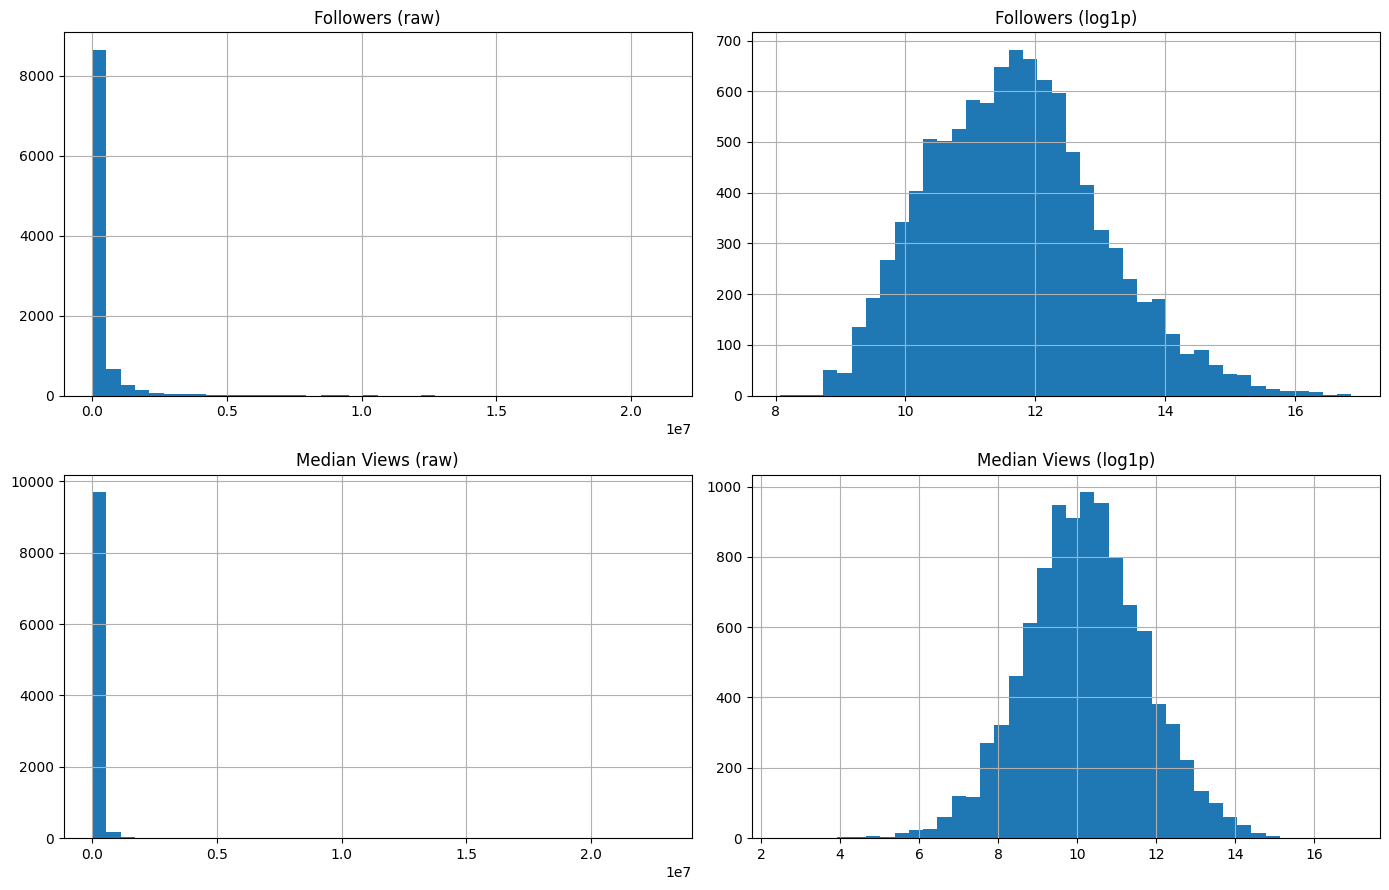

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

df['followers_num'].dropna().hist(ax=axes[0,0], bins=40)
axes[0,0].set_title('Followers (raw)')

df['followers_num_log1p'].dropna().hist(ax=axes[0,1], bins=40)
axes[0,1].set_title('Followers (log1p)')

df['median_views_num'].dropna().hist(ax=axes[1,0], bins=40)
axes[1,0].set_title('Median Views (raw)')

df['median_views_num_log1p'].dropna().hist(ax=axes[1,1], bins=40)
axes[1,1].set_title('Median Views (log1p)')

plt.tight_layout()
plt.show()

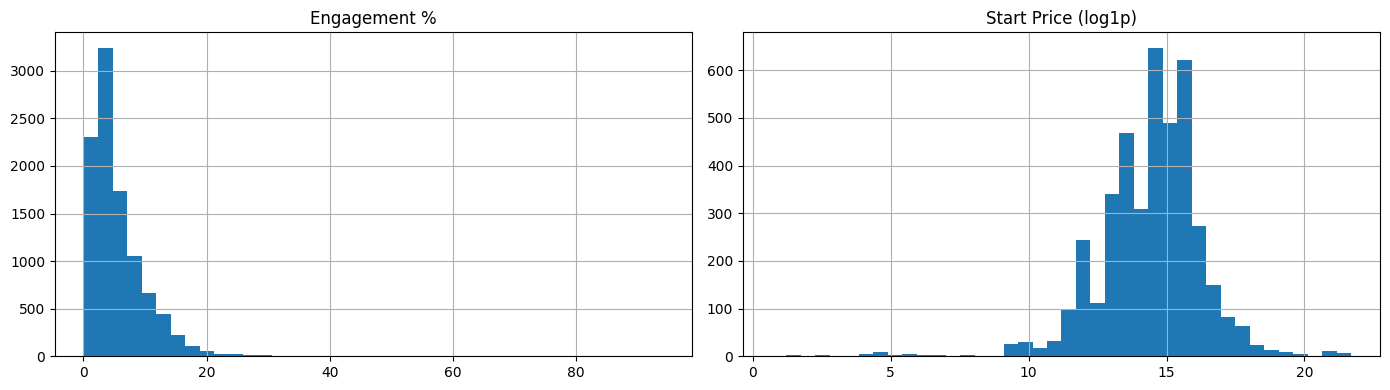

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['engagement_num'].dropna().hist(ax=axes[0], bins=40)
axes[0].set_title('Engagement %')

df['price_num_log1p'].dropna().hist(ax=axes[1], bins=40)
axes[1].set_title('Start Price (log1p)')

plt.tight_layout()
plt.show()

## BƯỚC 14. Trực quan hóa phân bổ quy mô, giá, và nhóm nội dung

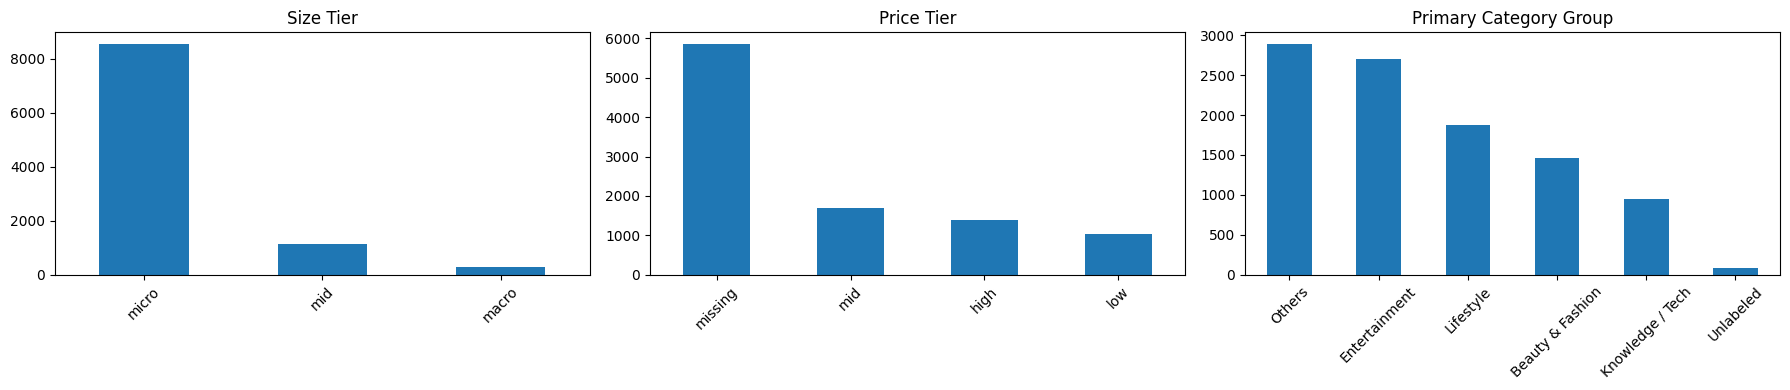

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

df['size_tier'].value_counts().plot(kind='bar', ax=axes[0], title='Size Tier')
df['price_tier'].value_counts().plot(kind='bar', ax=axes[1], title='Price Tier')
df['primary_category_group'].value_counts().head(10).plot(kind='bar', ax=axes[2], title='Primary Category Group')

for ax in axes:
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## BƯỚC 15. Bảng chéo phục vụ thiết kế sampling

In [19]:
sampling_crosstab_1 = pd.crosstab(df['size_tier'], df['price_tier'], margins=True)
sampling_crosstab_2 = pd.crosstab(df['size_tier'], df['primary_category_group'], margins=True)

print("=== Cross-tab: size_tier × price_tier ===")
display(sampling_crosstab_1)

print("=== Cross-tab: size_tier × primary_category_group ===")
display(sampling_crosstab_2)

=== Cross-tab: size_tier × price_tier ===


price_tier,high,low,mid,missing,All
size_tier,,,,,
macro,146,8,12,107,273
micro,871,974,1522,5187,8554
mid,369,45,158,567,1139
All,1386,1027,1692,5861,9966


=== Cross-tab: size_tier × primary_category_group ===


primary_category_group,Beauty & Fashion,Entertainment,Knowledge / Tech,Lifestyle,Others,Unlabeled,All
size_tier,,,,,,,
macro,30,47,20,38,134,4,273
micro,1257,2429,817,1635,2345,71,8554
mid,170,220,115,208,412,14,1139
All,1457,2696,952,1881,2891,89,9966
